# MOSAIQ Paper 2: tabular baseline and robustness results

This notebook generates Paper 2 tables and figures from the versioned MOSAIQ
tabular benchmark outputs. It does not load audio. ARAUS results use the shared
six-feature transfer baseline; Tong-style results use the reduced feature set
available in the current ISD package.

## tl;dr

The stochastic baselines are stable across five seeds, but test-sample and
cohort uncertainty materially affect interpretation. DeLTA source-conditioned
annoyance regression improves reliably over Target Mean. No reduced Tong-style
model reliably improves both ISD targets on held-out locations. ISD shared6
complete cases are a selected subset, and the current GPR intervals under-cover.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "benchmark").exists():
    ROOT = ROOT.parent
RESULTS = ROOT / "benchmark" / "results"
ROBUSTNESS = ROOT / "benchmark" / "robustness"
FIGURES = ROOT / "papers" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

metrics = pd.read_csv(RESULTS / "baseline_results.csv")
curves = pd.read_csv(RESULTS / "distribution_curves.csv")
multiseed = pd.read_csv(ROBUSTNESS / "multiseed_summary.csv")
bootstrap_ci = pd.read_csv(ROBUSTNESS / "bootstrap_intervals.csv")
paired = pd.read_csv(ROBUSTNESS / "paired_comparisons.csv")
coverage = pd.read_csv(ROBUSTNESS / "feature_coverage_sensitivity.csv")
calibration = pd.read_csv(ROBUSTNESS / "gpr_calibration.csv")
metrics.shape, curves.shape, bootstrap_ci.shape, paired.shape

((498, 16), (8020, 7), (123, 17), (34, 19))

## Response-level deterministic performance

All models in this table use the same ISD six-feature complete-case cohort:
1,324 training, 308 development, and 279 test responses.

In [2]:
response_test = metrics[
    (metrics["task_id"] == "isd_individual_iso_prediction")
    & (metrics["partition"] == "test")
    & (metrics["scope"] == "individual")
]
response_table = response_test.pivot_table(
    index=["model_id", "target", "n_train", "n_eval"],
    columns="metric",
    values="value",
).reset_index()
response_table.round(4)

metric,model_id,target,n_train,n_eval,mae,pearson_r,r2,rmse,spearman_rho
0,isd_response_target_mean_shared6,ISOEventful,1324,279,0.2690,NaN,-0.1883,0.3383,NaN
1,isd_response_target_mean_shared6,ISOPleasant,1324,279,0.2601,NaN,-0.0001,0.3103,NaN
2,tong_style_reduced_gpr,ISOEventful,1324,279,0.3053,-0.1047,-0.4552,0.3744,-0.1808
3,tong_style_reduced_gpr,ISOPleasant,1324,279,0.2719,0.0656,-0.1328,0.3302,0.0399
4,tong_style_reduced_lr,ISOEventful,1324,279,0.2783,0.0640,-0.2738,0.3503,0.0958
5,tong_style_reduced_lr,ISOPleasant,1324,279,0.2468,0.2947,0.0605,0.3007,0.3175
6,tong_style_reduced_rf,ISOEventful,1324,279,0.2540,0.2624,-0.0652,0.3203,0.2013
7,tong_style_reduced_rf,ISOPleasant,1324,279,0.2971,-0.0200,-0.3257,0.3572,-0.0405
8,tong_style_reduced_xgboost,ISOEventful,1324,279,0.2517,0.2790,-0.0587,0.3193,0.2173
9,tong_style_reduced_xgboost,ISOPleasant,1324,279,0.2867,0.0095,-0.2211,0.3429,-0.0271


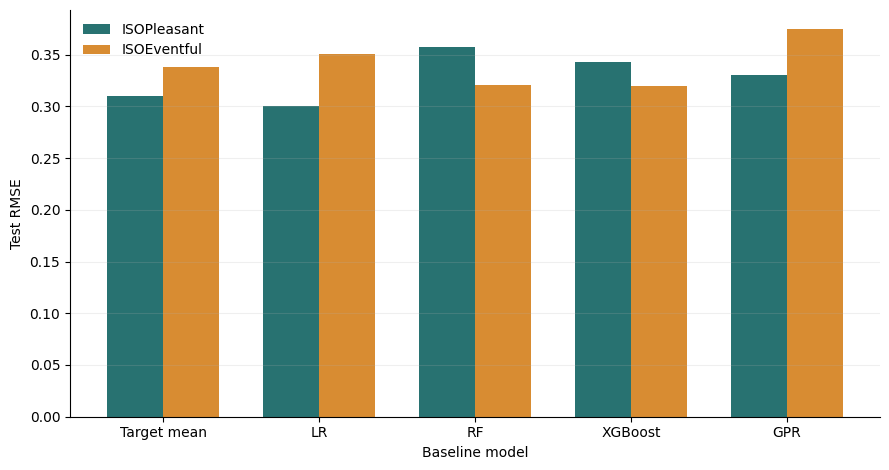

In [3]:
model_order = [
    "isd_response_target_mean_shared6",
    "tong_style_reduced_lr",
    "tong_style_reduced_rf",
    "tong_style_reduced_xgboost",
    "tong_style_reduced_gpr",
]
labels = ["Target mean", "LR", "RF", "XGBoost", "GPR"]
targets = ["ISOPleasant", "ISOEventful"]
colors = ["#287271", "#D88C32"]
x = np.arange(len(model_order))
width = 0.36

fig, ax = plt.subplots(figsize=(9, 4.8))
for index, target in enumerate(targets):
    values = [
        response_test[
            (response_test.model_id == model) &
            (response_test.target == target) &
            (response_test.metric == "rmse")
        ].value.iloc[0]
        for model in model_order
    ]
    ax.bar(x + (index - 0.5) * width, values, width, label=target, color=colors[index])
ax.set_xticks(x, labels)
ax.set_ylabel("Test RMSE")
ax.set_xlabel("Baseline model")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(FIGURES / "paper2_response_rmse.png", dpi=300, bbox_inches="tight")
plt.show()

## Group-level distribution comparison

In [4]:
distribution_table = metrics[
    (metrics["task_id"] == "isd_individual_iso_prediction")
    & (metrics["partition"] == "test")
    & (metrics["scope"] == "group_kde")
].pivot_table(index=["model_id", "target"], columns="metric", values="value")
distribution_table.round(4)

metric                                           dme  js_divergence  \
model_id                         target                               
isd_response_target_mean_shared6 ISOEventful  0.7201         0.3627   
                                 ISOPleasant  0.7535         0.3916   
tong_style_reduced_gpr           ISOEventful  0.4189         0.1517   
                                 ISOPleasant  0.4695         0.1629   
tong_style_reduced_lr            ISOEventful  0.3844         0.1413   
                                 ISOPleasant  0.4168         0.1526   
tong_style_reduced_rf            ISOEventful  0.4317         0.1423   
                                 ISOPleasant  0.4003         0.1350   
tong_style_reduced_xgboost       ISOEventful  0.3838         0.1207   
                                 ISOPleasant  0.4467         0.1507   

metric                                        kl_divergence  
model_id                         target                      
isd_response_target_mean_shared6 ISOEventful        11.7603  
                                 ISOPleasant        11.9138  
tong_style_reduced_gpr           ISOEventful         2.5987  
                                 ISOPleasant         1.9656  
tong_style_reduced_lr            ISOEventful         3.1759  
                                 ISOPleasant         3.1915  
tong_style_reduced_rf            ISOEventful         2.4860  
                                 ISOPleasant         1.6865  
tong_style_reduced_xgboost       ISOEventful         1.7493  
                                 ISOPleasant         1.6339

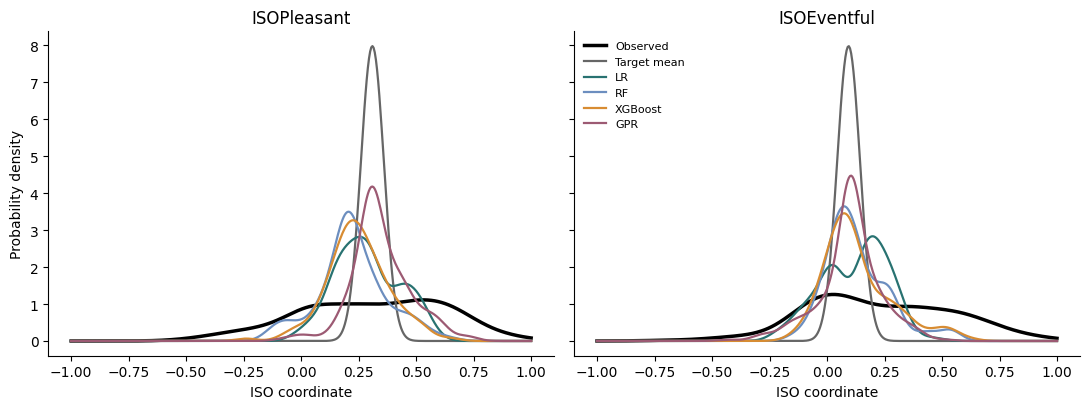

In [5]:
line_colors = ["#666666", "#287271", "#6C8EBF", "#D88C32", "#9C5A73"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, target in zip(axes, targets):
    target_curves = curves[(curves.partition == "test") & (curves.target == target)]
    observed = target_curves[target_curves.model_id == model_order[0]]
    ax.plot(observed.grid, observed.observed_density, color="black", lw=2.5, label="Observed")
    for model, label, color in zip(model_order, labels, line_colors):
        model_curve = target_curves[target_curves.model_id == model]
        ax.plot(model_curve.grid, model_curve.predicted_density, lw=1.6, color=color, label=label)
    ax.set_title(target)
    ax.set_xlabel("ISO coordinate")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Probability density")
axes[1].legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES / "paper2_response_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

## GPR observed versus predicted responses

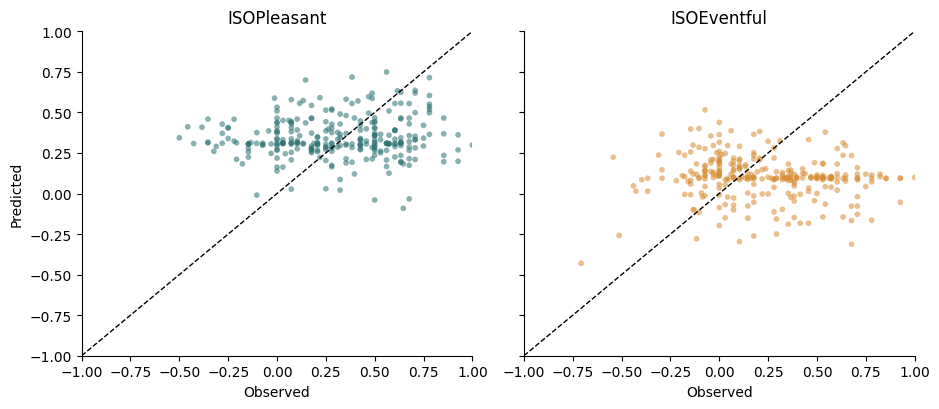

In [6]:
gpr_run = metrics[metrics.model_id == "tong_style_reduced_gpr"].run_id.iloc[0]
gpr = pd.read_csv(RESULTS / "predictions" / f"{gpr_run}.csv")
gpr = gpr[gpr.partition == "test"]
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2), sharex=True, sharey=True)
for ax, target, color in zip(axes, targets, colors):
    values = gpr[gpr.target == target]
    ax.scatter(values.y_true, values.y_pred, s=17, alpha=0.55, color=color, edgecolor="none")
    ax.plot([-1, 1], [-1, 1], color="black", lw=1, linestyle="--")
    ax.set_title(target)
    ax.set_xlabel("Observed")
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Predicted")
fig.tight_layout()
fig.savefig(FIGURES / "paper2_gpr_observed_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

## Clip-level reference baselines

In [7]:
clip_table = metrics[
    (metrics.partition == "test")
    & (metrics.scope == "record")
    & (metrics.metric.isin(["rmse", "mae", "r2"]))
].pivot_table(
    index=["task_id", "dataset_id", "feature_set", "model_id", "target", "n_train", "n_eval"],
    columns="metric",
    values="value",
).reset_index()
clip_table.round(4)

metric,task_id,dataset_id,feature_set,model_id,target,n_train,n_eval,mae,r2,rmse
0,araus_pleasantness_regression,ARAUS,laeq,araus_laeq_ridge,mean_ISOPleasant,17730,48,0.2224,0.2298,0.2701
1,araus_pleasantness_regression,ARAUS,none,araus_target_mean,mean_ISOPleasant,17730,48,0.2798,-0.2013,0.3374
2,araus_pleasantness_regression,ARAUS,shared6,araus_elastic_net_shared6,mean_ISOPleasant,17730,48,0.2374,0.1860,0.2777
3,araus_pleasantness_regression,ARAUS,shared6,araus_psychoacoustic_ridge,mean_ISOPleasant,17730,48,0.2356,0.1952,0.2762
4,delta_annoyance,DeLTA,delta_source_indicators,delta_annoyance_from_observed_sources_rf,mean_annoyance,2012,437,1.0223,0.1463,1.2484
5,delta_annoyance,DeLTA,delta_source_indicators,delta_annoyance_from_observed_sources_ridge,mean_annoyance,2012,437,1.0131,0.1503,1.2455
6,delta_annoyance,DeLTA,none,delta_annoyance_target_mean,mean_annoyance,2012,437,1.1244,-0.0006,1.3516
7,iso_coordinate_regression,ISD,laeq,isd_clip_laeq_ridge,mean_ISOEventful,784,184,0.2214,-0.0951,0.2832
8,iso_coordinate_regression,ISD,laeq,isd_clip_laeq_ridge,mean_ISOPleasant,784,184,0.2245,0.0848,0.2701
9,iso_coordinate_regression,ISD,none,isd_clip_target_mean,mean_ISOEventful,1599,581,0.1828,-0.0077,0.2383


## Step 7 methods

1. **Multi-seed stability:** retrain RF and XGBoost with five fixed seeds to
   measure estimator randomness.
2. **Cluster bootstrap:** resample test `clip_id` values 2,000 times and keep all
   responses from the same soundscape together to obtain 95% percentile CIs.
3. **Paired comparison:** align candidate and reference predictions on identical
   records, then bootstrap their metric difference. Positive improvement always
   favours the candidate.
4. **Coverage sensitivity:** compare all eligible ISD records with shared6
   complete cases within each released partition.
5. **GPR calibration:** compare nominal 50%, 80%, and 95% Gaussian prediction
   intervals with empirical test coverage.

## Multi-seed stability

In [8]:
seed_rmse = multiseed[
    (multiseed.partition == "test")
    & (multiseed.metric == "rmse")
    & (multiseed.scope.isin(["individual", "record"]))
].copy()
seed_rmse["label"] = seed_rmse["model_id"].str.replace("tong_style_reduced_", "", regex=False)
seed_rmse["label"] = seed_rmse["label"].str.replace("delta_annoyance_from_observed_sources_", "delta ", regex=False)
seed_rmse["label"] = seed_rmse["label"] + " / " + seed_rmse["target"]
seed_rmse[["model_id", "target", "mean", "std", "minimum", "maximum", "n_seeds"]].round(4)

,model_id,target,mean,std,minimum,maximum,n_seeds
8,delta_annoyance_from_observed_sources_rf,mean_annoyance,1.2467,0.0012,1.2455,1.2484,5
32,tong_style_reduced_rf,ISOEventful,0.3204,0.0008,0.3196,0.3215,5
40,tong_style_reduced_rf,ISOPleasant,0.3567,0.0013,0.3554,0.3586,5
64,tong_style_reduced_xgboost,ISOEventful,0.3211,0.0015,0.3193,0.3226,5
72,tong_style_reduced_xgboost,ISOPleasant,0.3442,0.0034,0.3403,0.3494,5


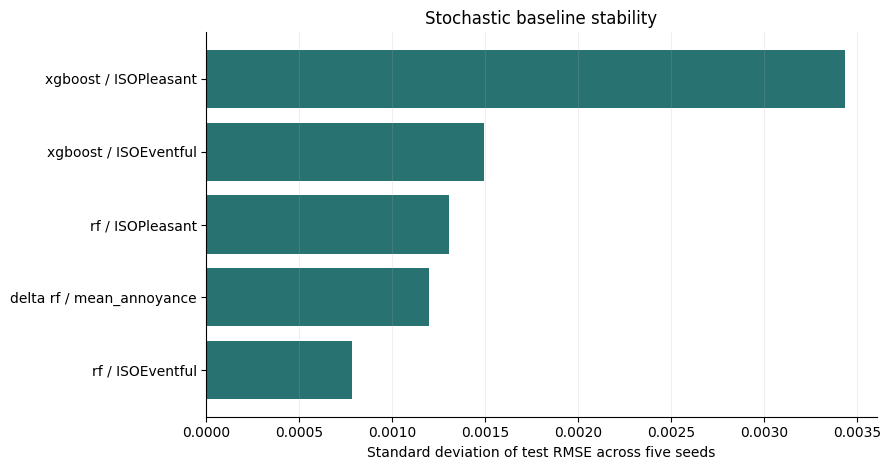

In [9]:
seed_plot = seed_rmse.sort_values("std", ascending=True).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9, 4.8))
y = np.arange(len(seed_plot))
ax.barh(y, seed_plot["std"], color="#287271")
ax.set_yticks(y, seed_plot["label"])
ax.set_xlabel("Standard deviation of test RMSE across five seeds")
ax.set_ylabel("")
ax.set_title("Stochastic baseline stability")
ax.grid(axis="x", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES / "paper2_multiseed_stability.png", dpi=300, bbox_inches="tight")
plt.show()

## Cluster-bootstrap confidence intervals

In [10]:
selected_ci = bootstrap_ci[
    (bootstrap_ci.metric == "rmse")
    & (bootstrap_ci.model_id.isin(model_order + [
        "delta_annoyance_target_mean",
        "delta_annoyance_from_observed_sources_ridge",
        "delta_annoyance_from_observed_sources_rf",
    ]))
][["task_id", "model_id", "target", "estimate", "ci_low", "ci_high", "n_eval", "n_clusters"]]
selected_ci.round(4)

,task_id,model_id,target,estimate,ci_low,ci_high,n_eval,n_clusters
23,delta_annoyance,delta_annoyance_from_observed_sources_rf,mean_annoyance,1.2484,1.1708,1.3247,437,437
28,delta_annoyance,delta_annoyance_from_observed_sources_ridge,mean_annoyance,1.2455,1.1667,1.3261,437,437
33,delta_annoyance,delta_annoyance_target_mean,mean_annoyance,1.3516,1.2725,1.4304,437,437
46,isd_individual_iso_prediction,isd_response_target_mean_shared6,ISOEventful,0.3383,0.3093,0.3666,279,184
51,isd_individual_iso_prediction,isd_response_target_mean_shared6,ISOPleasant,0.3103,0.2900,0.3319,279,184
56,isd_individual_iso_prediction,tong_style_reduced_gpr,ISOEventful,0.3744,0.3428,0.4030,279,184
61,isd_individual_iso_prediction,tong_style_reduced_gpr,ISOPleasant,0.3302,0.3062,0.3537,279,184
66,isd_individual_iso_prediction,tong_style_reduced_lr,ISOEventful,0.3503,0.3152,0.3829,279,184
71,isd_individual_iso_prediction,tong_style_reduced_lr,ISOPleasant,0.3007,0.2767,0.3251,279,184
76,isd_individual_iso_prediction,tong_style_reduced_rf,ISOEventful,0.3203,0.2920,0.3493,279,184


## Paired improvement over the declared reference

In [11]:
paired_rmse = paired[paired.metric == "rmse"].copy()
paired_rmse["label"] = paired_rmse["candidate_model"].str.replace("tong_style_reduced_", "", regex=False)
paired_rmse["label"] = paired_rmse["label"].str.replace("delta_annoyance_from_observed_sources_", "delta ", regex=False)
paired_rmse["label"] = paired_rmse["label"] + " / " + paired_rmse["target"]
paired_rmse[["candidate_model", "target", "improvement", "ci_low", "ci_high", "probability_improvement_gt_zero"]].round(4)

,candidate_model,target,improvement,ci_low,ci_high,probability_improvement_gt_zero
2,delta_annoyance_from_observed_sources_rf,mean_annoyance,0.1032,0.0378,0.1648,1.0000
5,delta_annoyance_from_observed_sources_ridge,mean_annoyance,0.1061,0.0544,0.1596,1.0000
12,tong_style_reduced_gpr,ISOEventful,-0.0361,-0.0529,-0.0205,0.0000
15,tong_style_reduced_gpr,ISOPleasant,-0.0199,-0.0332,-0.0073,0.0005
18,tong_style_reduced_lr,ISOEventful,-0.0120,-0.0376,0.0127,0.1765
21,tong_style_reduced_lr,ISOPleasant,0.0096,-0.0080,0.0272,0.8690
24,tong_style_reduced_rf,ISOEventful,0.0180,-0.0027,0.0377,0.9545
27,tong_style_reduced_rf,ISOPleasant,-0.0469,-0.0686,-0.0260,0.0000
30,tong_style_reduced_xgboost,ISOEventful,0.0190,-0.0014,0.0402,0.9655
33,tong_style_reduced_xgboost,ISOPleasant,-0.0326,-0.0508,-0.0144,0.0005


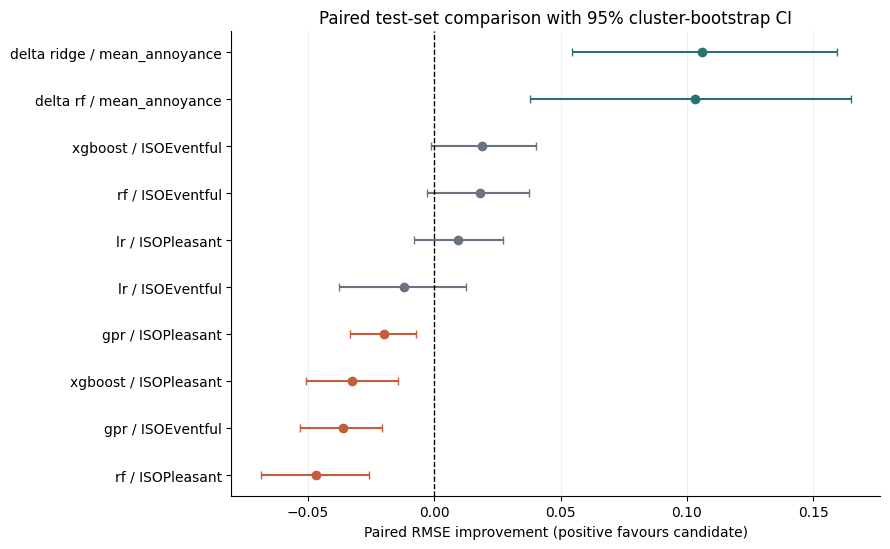

In [12]:
paired_plot = paired_rmse.sort_values("improvement").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9, 5.6))
y = np.arange(len(paired_plot))
xerr = np.vstack([
    paired_plot["improvement"] - paired_plot["ci_low"],
    paired_plot["ci_high"] - paired_plot["improvement"],
])
colors_ci = np.where(paired_plot["ci_low"] > 0, "#287271", np.where(paired_plot["ci_high"] < 0, "#C65D3A", "#6B7280"))
for index in range(len(paired_plot)):
    ax.errorbar(paired_plot.loc[index, "improvement"], y[index], xerr=xerr[:, index:index+1], fmt="o", color=colors_ci[index], capsize=3)
ax.axvline(0, color="black", lw=1, linestyle="--")
ax.set_yticks(y, paired_plot["label"])
ax.set_xlabel("Paired RMSE improvement (positive favours candidate)")
ax.set_ylabel("")
ax.set_title("Paired test-set comparison with 95% cluster-bootstrap CI")
ax.grid(axis="x", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES / "paper2_paired_rmse_improvement.png", dpi=300, bbox_inches="tight")
plt.show()

## ISD feature coverage and GPR calibration

In [13]:
coverage_test = coverage[
    (coverage.partition == "test") & (coverage.cohort == "shared6_complete")
].drop_duplicates("task_id")
coverage_test[["task_id", "unit_of_analysis", "n_records", "n_all_eligible", "coverage_fraction"]].round(4), calibration.round(4)

(                          task_id unit_of_analysis  n_records  n_all_eligible  \
 6   isd_individual_iso_prediction         response        279             685   
 18      iso_coordinate_regression             clip        184             581   
 
     coverage_fraction  
 6              0.4073  
 18             0.3167  ,
                          task_id                model_id partition  \
 0  isd_individual_iso_prediction  tong_style_reduced_gpr      test   
 1  isd_individual_iso_prediction  tong_style_reduced_gpr      test   
 2  isd_individual_iso_prediction  tong_style_reduced_gpr      test   
 3  isd_individual_iso_prediction  tong_style_reduced_gpr      test   
 4  isd_individual_iso_prediction  tong_style_reduced_gpr      test   
 5  isd_individual_iso_prediction  tong_style_reduced_gpr      test   
 
         target  nominal_coverage  empirical_coverage  calibration_error  \
 0  ISOEventful              0.50              0.3154            -0.1846   
 1  ISOEventful          

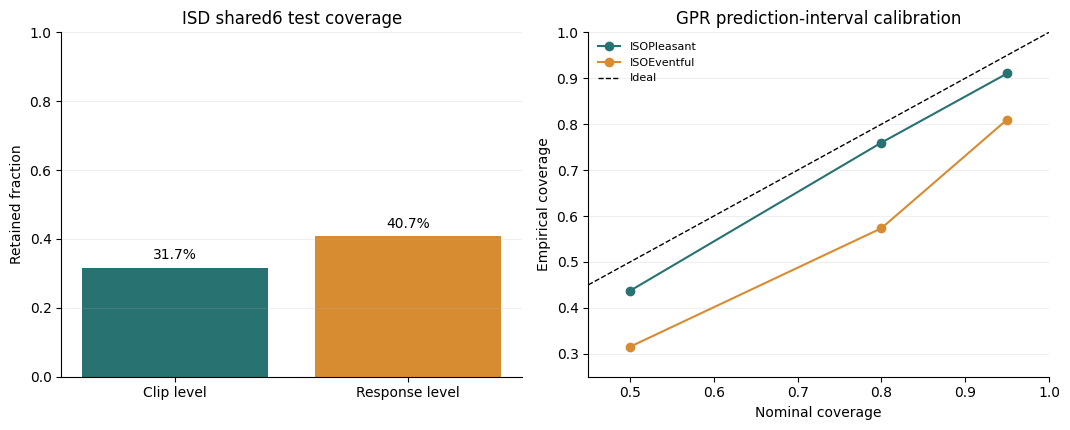

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.4))
coverage_labels = ["Clip level", "Response level"]
coverage_values = [
    coverage_test.loc[coverage_test.unit_of_analysis == "clip", "coverage_fraction"].iloc[0],
    coverage_test.loc[coverage_test.unit_of_analysis == "response", "coverage_fraction"].iloc[0],
]
axes[0].bar(coverage_labels, coverage_values, color=["#287271", "#D88C32"])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Retained fraction")
axes[0].set_title("ISD shared6 test coverage")
for index, value in enumerate(coverage_values):
    axes[0].text(index, value + 0.025, f"{value:.1%}", ha="center")

for target, color in zip(targets, colors):
    values = calibration[calibration.target == target]
    axes[1].plot(values.nominal_coverage, values.empirical_coverage, marker="o", color=color, label=target)
axes[1].plot([0.45, 1.0], [0.45, 1.0], color="black", lw=1, linestyle="--", label="Ideal")
axes[1].set_xlim(0.45, 1.0)
axes[1].set_ylim(0.25, 1.0)
axes[1].set_xlabel("Nominal coverage")
axes[1].set_ylabel("Empirical coverage")
axes[1].set_title("GPR prediction-interval calibration")
axes[1].legend(frameon=False, fontsize=8)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(FIGURES / "paper2_coverage_and_calibration.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation boundary

These outputs establish reproducible no-audio reference performance. They do
not constitute an exact replication of the ARAUS 264-candidate Elastic Net or
the full Tong et al. feature set. Negative or weak held-out-location results
must be reported as benchmark evidence rather than hidden by random response
splitting. Bootstrap intervals quantify uncertainty in the released test sample,
not transfer to a new dataset. The strong ISD complete-case shifts and GPR
under-coverage are technical-validation findings, not defects to conceal.